# Bone Microarchitecture Example

- **By:** [Michael T. Kuczynski](https://www.linkedin.com/in/mkuczyns/), Sarah Elmahdy 2025 
- **License:** CC-BY 
- **How to cite:** Cite the ORMIR_XCT publication: *Kuczynski et al., (2024). ORMIR_XCT: A Python package for high resolution peripheral quantitative computed tomography image processing. Journal of Open Source Software, 9(97), 6084, https://doi.org/10.21105/joss.06084*

---
# Aims

- This Jupyter Notebook provides an example of computing bone microarchitecture from HR-pQCT scans, including volumetric bone mineral density (vBMD), bone volume fraction (BV/TV), trabecular thickness (Tb.Th), trabecular separation (Tb.Sp), and trabecular number (Tb.N), cortical thickness (Ct.Th).

  **Table of contents**  
  [Step 1: Imports](#imports)   
  [Step 2: Setup](#setup)   
  [Step 3: Bone Mineral Density (BMD)](#bmd)   
  [Step 4: Bone Volume Fraction (BV/TV)](#bvtv)   
  [Step 5: Trabecular Thickness (Tb.Th)](#tbth)   
  [Step 6: Trabecular Separation (Tb.Sp)](#tbsp)   
  [Step 7: Trabecular Number (Tb.N)](#tbn)   
  [Step 8: Total Bone Area](#tba)


---

<a name="imports"></a>
## *Step 1: Imports*

Import modules/packages and set the input image path. 

In [1]:
import os
import sys
import numpy as np
import SimpleITK as sitk

from matplotlib import pyplot as plt

from ormir_xct.bone_parameters.bone_parameters import calculate_bone_parameter, trab_peri_array
from ormir_xct.segmentation.ipl_seg import ipl_seg
from ormir_xct.autocontour.autocontour import autocontour
from ormir_xct.util.hildebrand_thickness import calc_structure_thickness_statistics

---

<a name="setup"></a>
## *Step 2: Setup*

In [5]:
# Define header information (pulled from original AIM image)
mu_scaling = 8192
mu_water = 0.24090
rescale_slope = 1603.51904
rescale_intercept = -391.209015

In [6]:
# Read in grayscale example image and run the standard trabecular bone segmentation
gray_image_path = os.path.join("images", "GRAY_JOINT.nii")
gray_img = sitk.ReadImage(gray_image_path, sitk.sitkFloat32)
gray_img_np = sitk.GetArrayFromImage(gray_img)

# Assume isotropic voxels
spacing = gray_img.GetSpacing()

In [7]:
# Use standard threshold values in HU and generate the periosteal and endosteal segmentations
trab_seg, peri_mask, trab_seg_np, peri_mask_np = trab_peri_array(gray_img, spacing, mu_water, rescale_slope, rescale_intercept)

In [8]:
# Define the pre-set slice
slice_index = peri_mask_np.shape[0] // 2


---

<a name="vbmd"></a>
## *Step 3: Bone Mineral Density (BMD)*

<img src="images/table_header_2.png">
<img src="images/total_bone_mineral_density.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

## Take screenshots of the calculations and show difference and explain
## use scypy or something for skelenization and see if there is a difference between, mean, min, max and std between different libraries --- can't figure out how to use other libraries...not working


In [ ]:
mean, std = calculate_bone_parameter(gray_image_path, "bmd", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco")


mean bone mineral density is -459.86684790101566 +/- 134.6328194300135


In [ ]:
# Didn't do conversions so output different
# DO NOT RUN!
# REFERENCE FOR NOW
mean, std = calculate_bone_parameter(gray_image_path, "bmd", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco")


mean bone mineral density mask is -350.7567347873444 +/- 687.8073508055234


In [ ]:
# Not sure which one is the mask
mean, std = calculate_bone_parameter(gray_image_path, "bmdmask", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco", peri_mask)

mean bone mineral density mask is -281.2384952974339 +/- 114.70892610999651


(-281.2384952974339, 114.70892610999651)

In [ ]:
# Not sure which one is the mask
mean, std = calculate_bone_parameter(gray_image_path, "bmdmask", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco", trab_seg)

mean bone mineral density mask is -81.63780922444475 +/- 64.93375882914296


(-81.63780922444475, 64.93375882914296)

---

# Both are using sitk

In [ ]:
mean, std = calculate_bone_parameter(gray_image_path, "bmd", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco")

mean, std = calculate_bone_parameter(gray_image_path, "bmdmask", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco", peri_mask)

mean bone mineral density is -459.86684790101566 +/- 134.6328194300135
mean bone mineral density mask is -459.8668644433273 +/- 134.63283482282904


---

# both are using numpy

In [ ]:
mean, std = calculate_bone_parameter(gray_image_path, "bmd", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco")

mean, std = calculate_bone_parameter(gray_image_path, "bmdmask", mu_scaling, mu_water, rescale_slope, rescale_intercept, "scanco", peri_mask)

mean bone mineral density is -459.8668644433312 +/- 134.63283259393282
mean bone mineral density mask is -281.2384952974339 +/- 114.70892610999651


---

<a name="bvtv"></a>
## *Step 4: Bone Volume Fraction (BV/TV)*

<img src="images/table_headers.png">
<img src="images/bone_volume_fraction.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

In [ ]:
bvtv = calculate_bone_parameter(gray_image_path, "bv", mu_scaling, mu_water, rescale_slope, rescale_intercept)

BV/TV = 0.1459180081383874


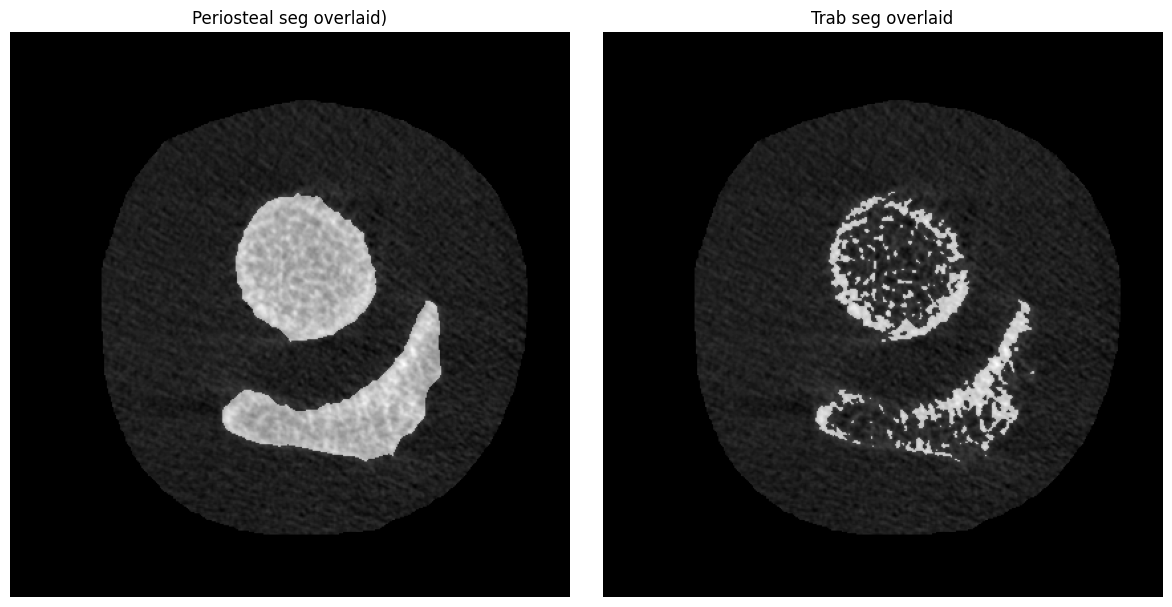

In [ ]:
plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.imshow(peri_mask_np[slice_index, :, :], cmap="gray", alpha=0.5)
plt.title("Periosteal seg overlaid)")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray", alpha=0.5)
plt.title("Trab seg overlaid")
plt.axis("off")

plt.tight_layout()
plt.show()

---

<a name="tbth"></a>
## *Step 5: Trabecular Thickness (Tb.Th)*

<img src="images/table_headers.png">
<img src="images/trabecular_thickness.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

In [ ]:
img_np, trabecular_thickness = calculate_bone_parameter(gray_image_path, "tb.th", mu_scaling, mu_water, rescale_slope, rescale_intercept)


mean thickness is 0.27423076418232106 +/- 0.1147563895748098
max thickness is 0.6649255902415407


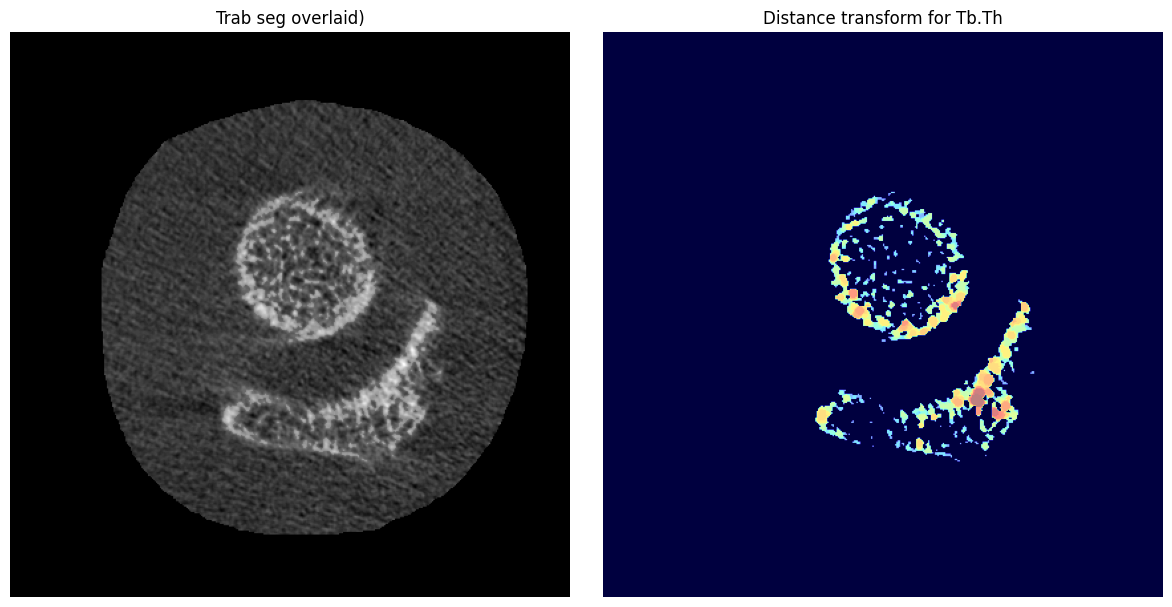

In [ ]:
trabecular_thickness_np = sitk.GetArrayFromImage(img_np)

plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray", alpha=0.1)
plt.title("Trab seg overlaid)")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray")
plt.imshow(trabecular_thickness_np[slice_index, :, :], cmap="jet", alpha=0.5)
plt.title("Distance transform for Tb.Th")
plt.axis("off")

plt.tight_layout()
plt.show()

---

<a name="tbsp"></a>
## *Step 6: Trabecular Separation (Tb.Sp)*

<img src="images/table_headers.png">
<img src="images/trabecular_separation.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

In [ ]:
img_np, trabecular_separation = calculate_bone_parameter(gray_image_path, "tb.sp", mu_scaling, mu_water, rescale_slope, rescale_intercept)

mean separation is 0.8776243585382155 +/- 0.4115064301421036
max separation is 2.440077216410531


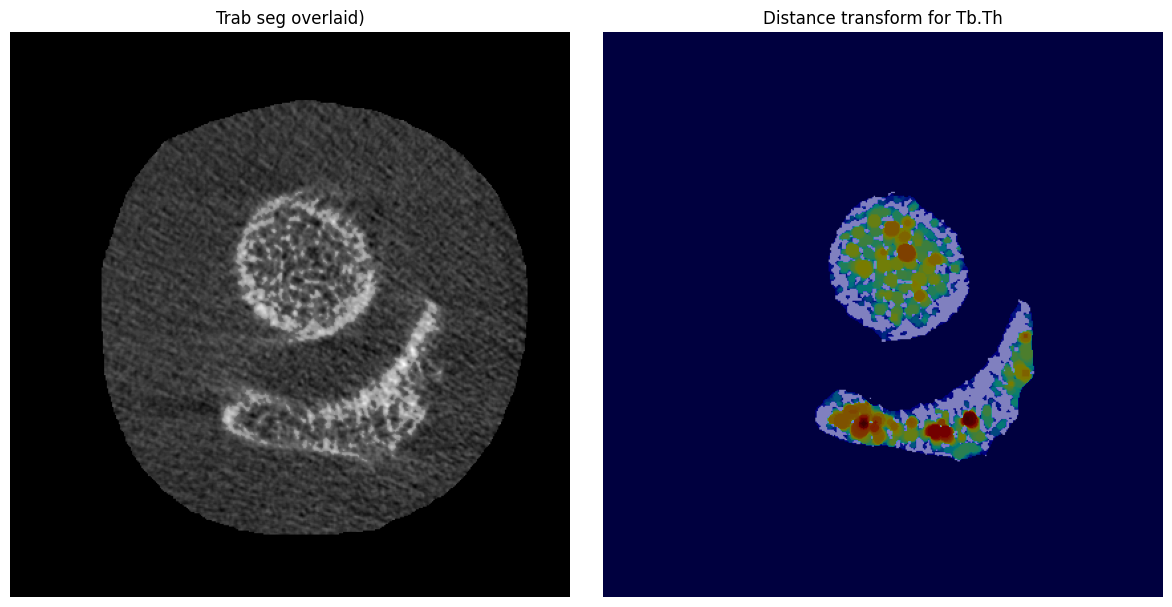

In [ ]:
trabecular_separation_np = sitk.GetArrayFromImage(img_np)

plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray", alpha=0.1)
plt.title("Trab seg overlaid)")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray")
plt.imshow(trabecular_separation_np[slice_index, :, :], cmap="jet", alpha=0.5)
plt.title("Distance transform for Tb.Th")
plt.axis("off")

plt.tight_layout()
plt.show()

---

<a name="tbn"></a>
## *Step 7: Trabecular Number (Tb.N)*

<img src="images/table_headers.png">
<img src="images/trabecular_number.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

In [ ]:
# Defined in Figure 4 of https://doi.org/10.1259/dmfr.20140196
# Tb.N = 1 / mean spacing between the midlines of the trabeculae
# First need to skeletonize the trabecular bone segmentation
# Then compute the distance transform of the skeleton
# The inverse of the mean of the distance transform will be Tb.N

img_np, trabecular_number = calculate_bone_parameter(gray_image_path, "tb.n", mu_scaling, mu_water, rescale_slope, rescale_intercept)

Trabecular Number (Tb.N) = 3.648199730047864


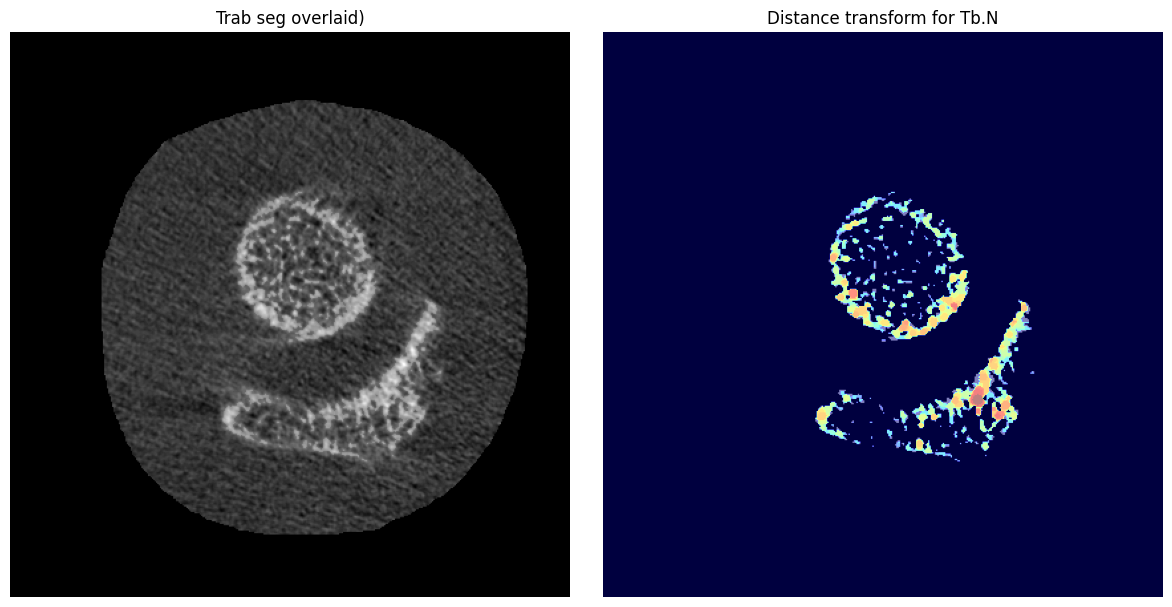

In [ ]:
trabecular_number_np = sitk.GetArrayFromImage(img_np)

plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray", alpha=0.1)
plt.title("Trab seg overlaid)")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(trab_seg_np[slice_index, :, :], cmap="gray")
plt.imshow(trabecular_number_np[slice_index, :, :], cmap="jet", alpha=0.5)
plt.title("Distance transform for Tb.N")
plt.axis("off")

plt.tight_layout()
plt.show()

<img src="images/trabecular_number_theory.gif">

cite: ???

Nathan J. Neeteson, Annabel R. Bugbird, Lauren A. Burt, Steven K. Boyd,
Statistical investigation of interdependence of trabecular microarchitectural parameters from micro-computed tomography,
Bone,
Volume 187,
2024,
117144,
ISSN 8756-3282,
https://doi.org/10.1016/j.bone.2024.117144.

In [ ]:

tb_n_theory = 1/(trabecular_thickness[0] + trabecular_separation[0])
print(tb_n_theory)

0.8681647372788741


---

<a name="tba"></a>
## *Step 8: Total Bone Area*

<img src="images/table_header_2.png">
<img src="images/total_area.png">

cite: Whittier, D., Boyd, S., Burghardt, A. et al. Guidelines for the assessment of bone density and microarchitecture in vivo using high-resolution peripheral quantitative computed tomography. Osteoporos Int 31, 1607–1627 (2020). https://doi.org/10.1007/s00198-020-05438-5

In [ ]:
tba = calculate_bone_parameter(gray_image_path, "tba", mu_scaling, mu_water, rescale_slope, rescale_intercept)


Total Bone Area = 18410.232568398565 mm^2


---

<a name="ctpo"></a>
## *Cortical Porosity (Ct.Po)*

---

<a name="compare"></a>
## *Compare IPL to ORMIR_XCT*

---